# Machine Learning Assignment 2 - Semi-Supervised Learning for Predicting Survival Time in Multiple Myeloma Patients
***
## Group Members
- Geri Aliaj - 75360
- Ben Moritz Castello - 75197
- Maria Teresa Viciosa - 75149

## Task 1 Setting the baseline

As in the previous assignment, the first step is to set a baseline. The ML task is regression, and we will fit a linear regression model as a baseline, which we can use to compare with further developments.

### Task 1.1 Data preparation and validation pipeline


In [70]:
# Importing the necessary libraries

import pandas as pd
import missingno as msno
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, FunctionTransformer
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline
import time
import random

In [71]:
train_csv = pd.read_csv('train_data.csv')
train_csv.head(150)

,Unnamed: 0,Age,Gender,Stage,GeneticRisk,TreatmentType,ComorbidityIndex,TreatmentResponse,SurvivalTime,Censored
0,0,65.0,0,2,1.0,0,0.0,0.0,4.2,0
1,1,68.0,1,2,0.0,1,1.0,1.0,4.7,1
2,2,68.0,1,3,1.0,1,0.0,1.0,3.5,1
3,3,81.0,1,4,1.0,1,3.0,0.0,2.3,0
4,4,59.0,1,2,1.0,0,NaN,0.0,NaN,0
...,...,...,...,...,...,...,...,...,...,...
145,145,45.0,0,2,0.0,0,NaN,1.0,2.0,0
146,146,81.0,1,4,NaN,0,2.0,0.0,NaN,0
147,147,66.0,1,4,0.0,0,1.0,1.0,NaN,0
148,148,73.0,1,3,0.0,0,2.0,1.0,NaN,0


In [72]:
train_csv.describe()

,Unnamed: 0,Age,Gender,Stage,GeneticRisk,TreatmentType,ComorbidityIndex,TreatmentResponse,SurvivalTime,Censored
count,400.000000,400.00000,400.000000,400.000000,315.000000,400.000000,355.000000,371.000000,240.000000,400.000000
mean,199.500000,65.14250,0.590000,2.565000,0.285714,0.412500,1.092958,0.514825,4.479583,0.197500
std,115.614301,9.55434,0.492449,1.081063,0.452473,0.492901,0.869983,0.500455,2.015370,0.398611
min,0.000000,40.00000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000
25%,99.750000,59.00000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
50%,199.500000,65.00000,1.000000,2.500000,0.000000,0.000000,1.000000,1.000000,4.100000,0.000000
75%,299.250000,72.00000,1.000000,4.000000,1.000000,1.000000,2.000000,1.000000,5.700000,0.000000
max,399.000000,90.00000,1.000000,4.000000,1.000000,1.000000,3.000000,1.000000,12.100000,1.000000


<Axes: >

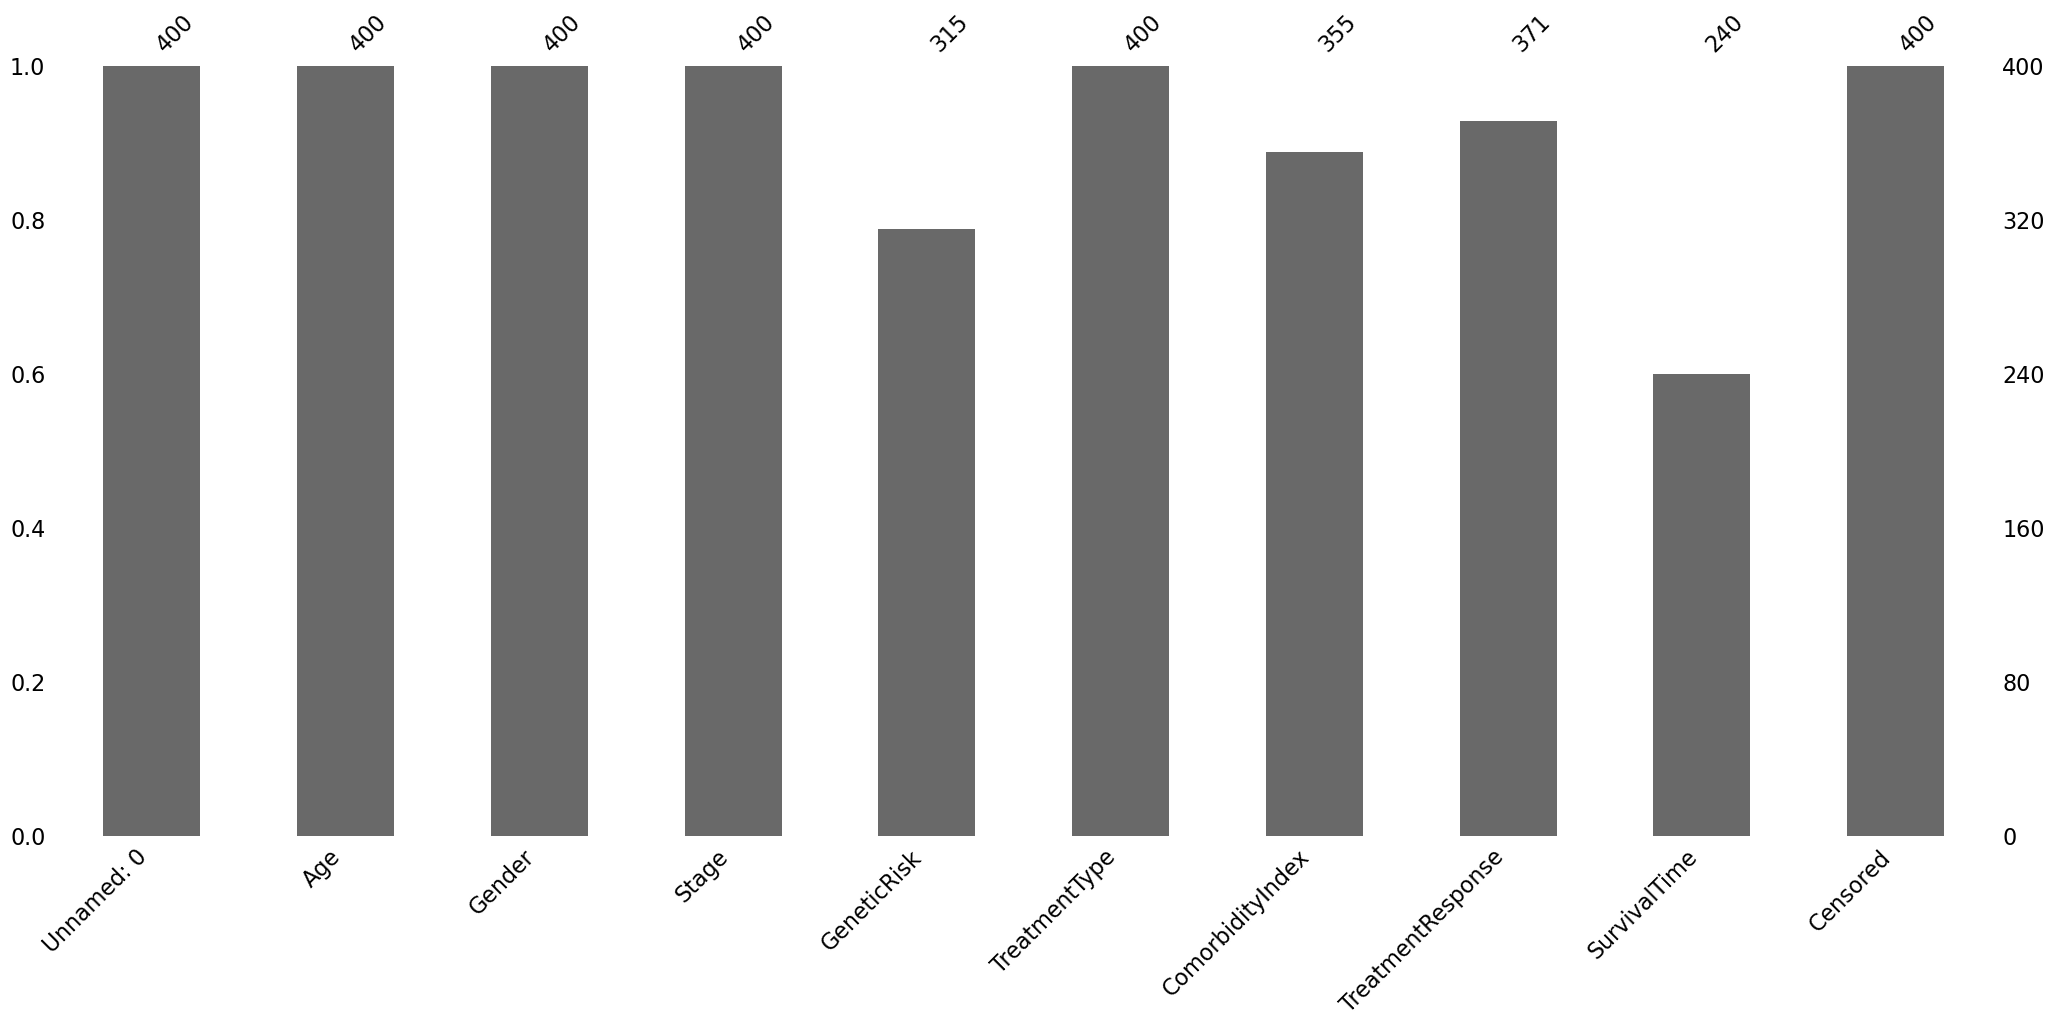

In [73]:
msno.bar(train_csv)

### How many cases are in the dataset?

In [74]:
# How many cases does our dataset have?
#num_rows = train_csv["id"].nunique()
#print(f"Total Number of cases: {num_rows}")

### Visualisation

<Axes: >

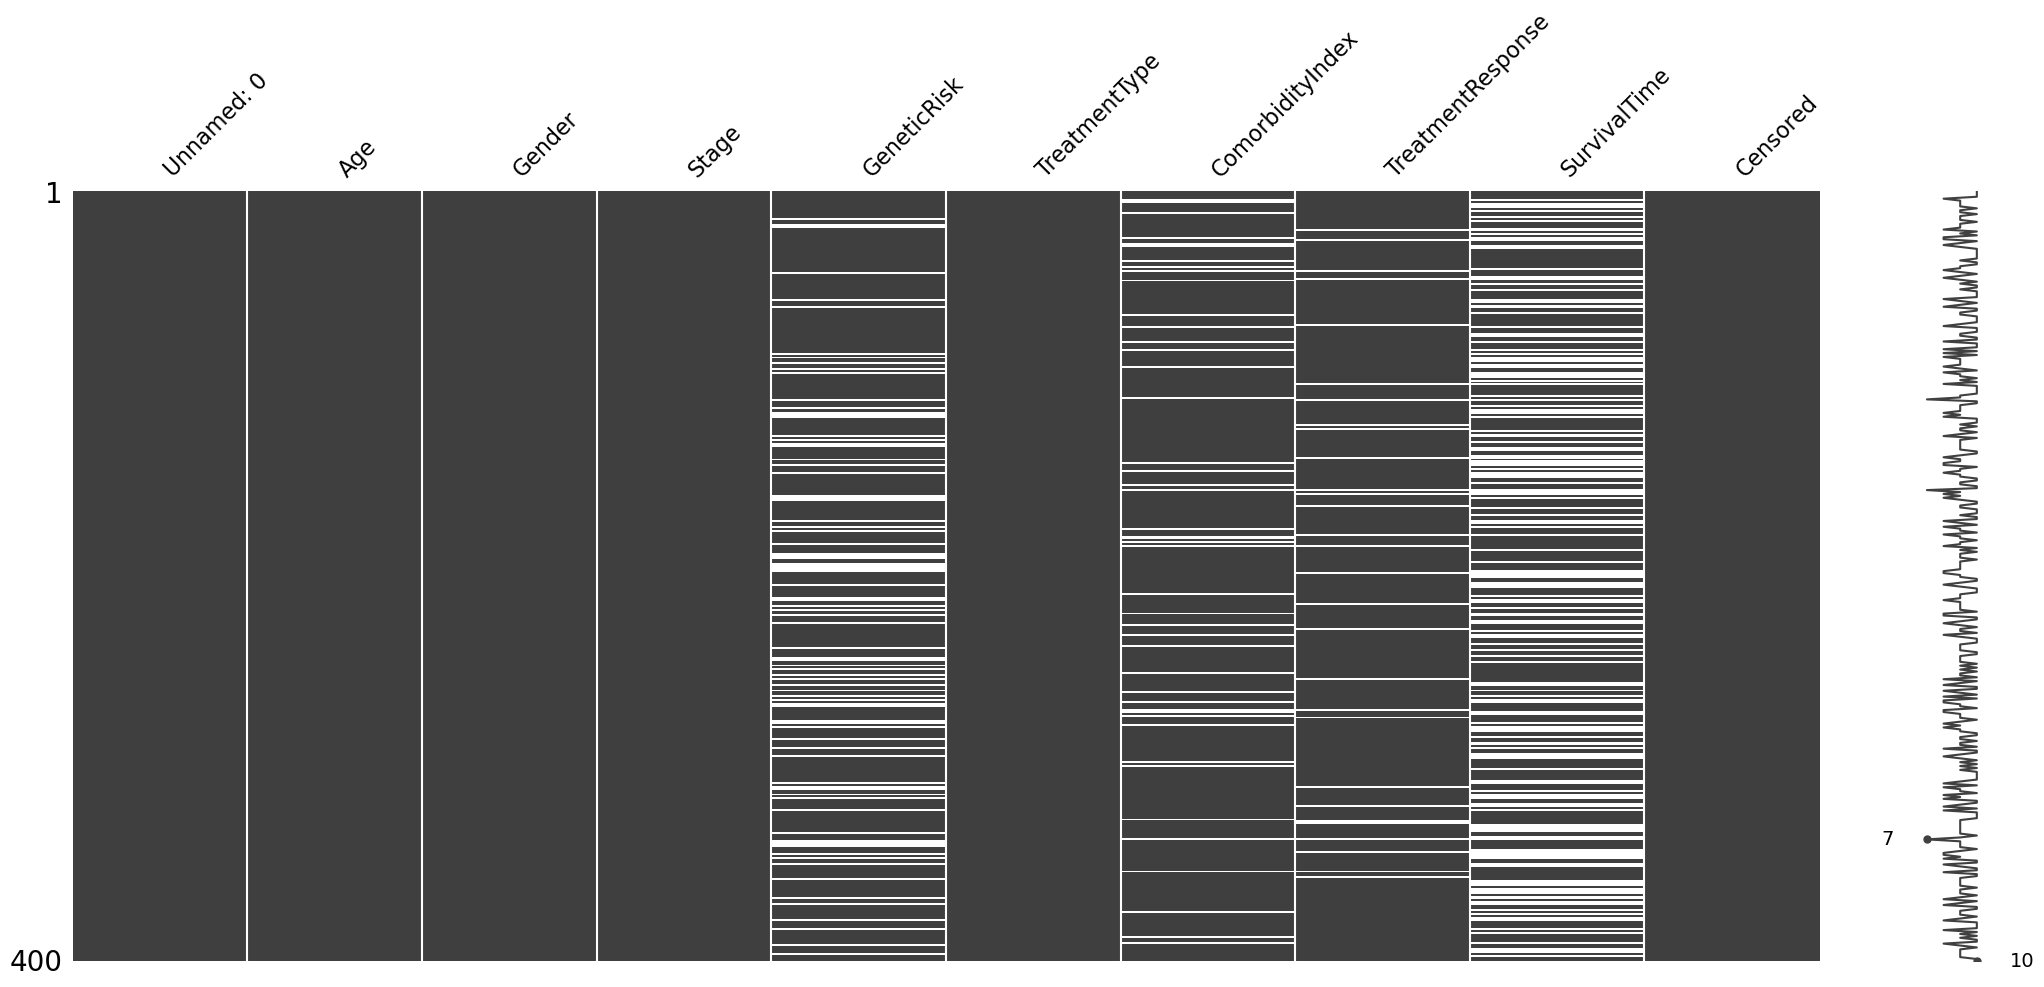

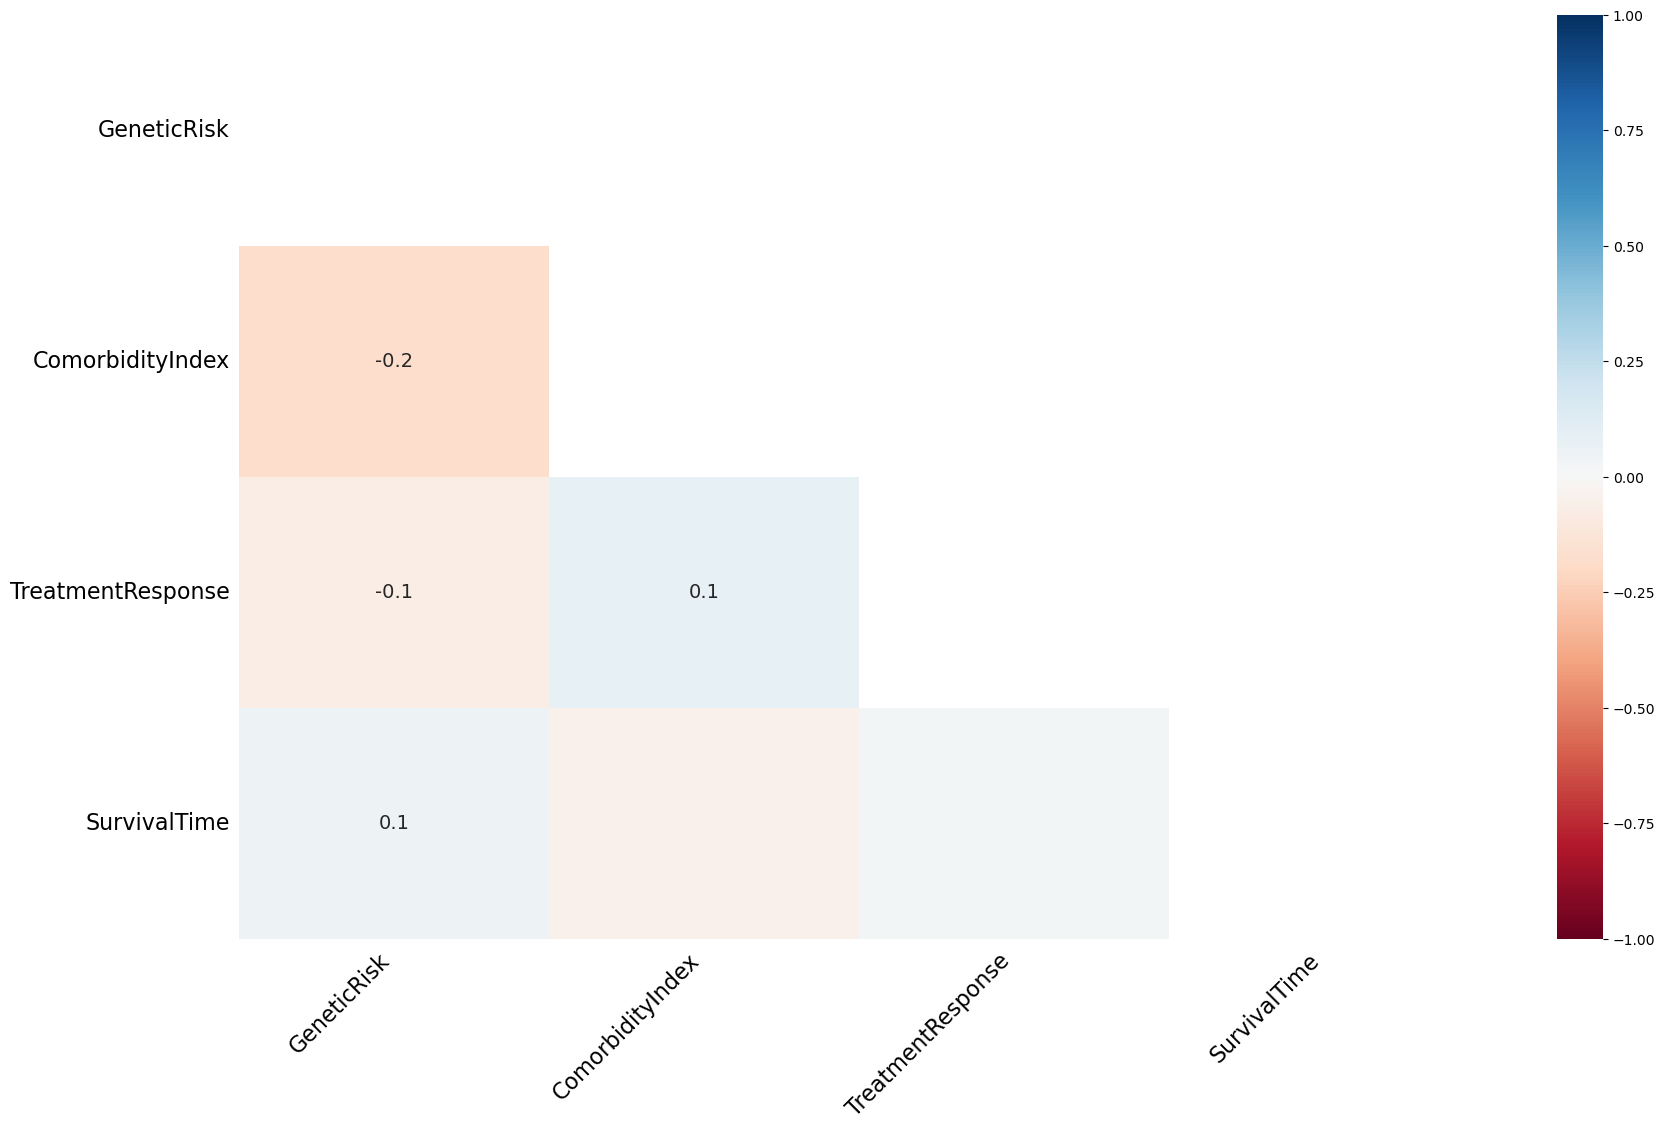

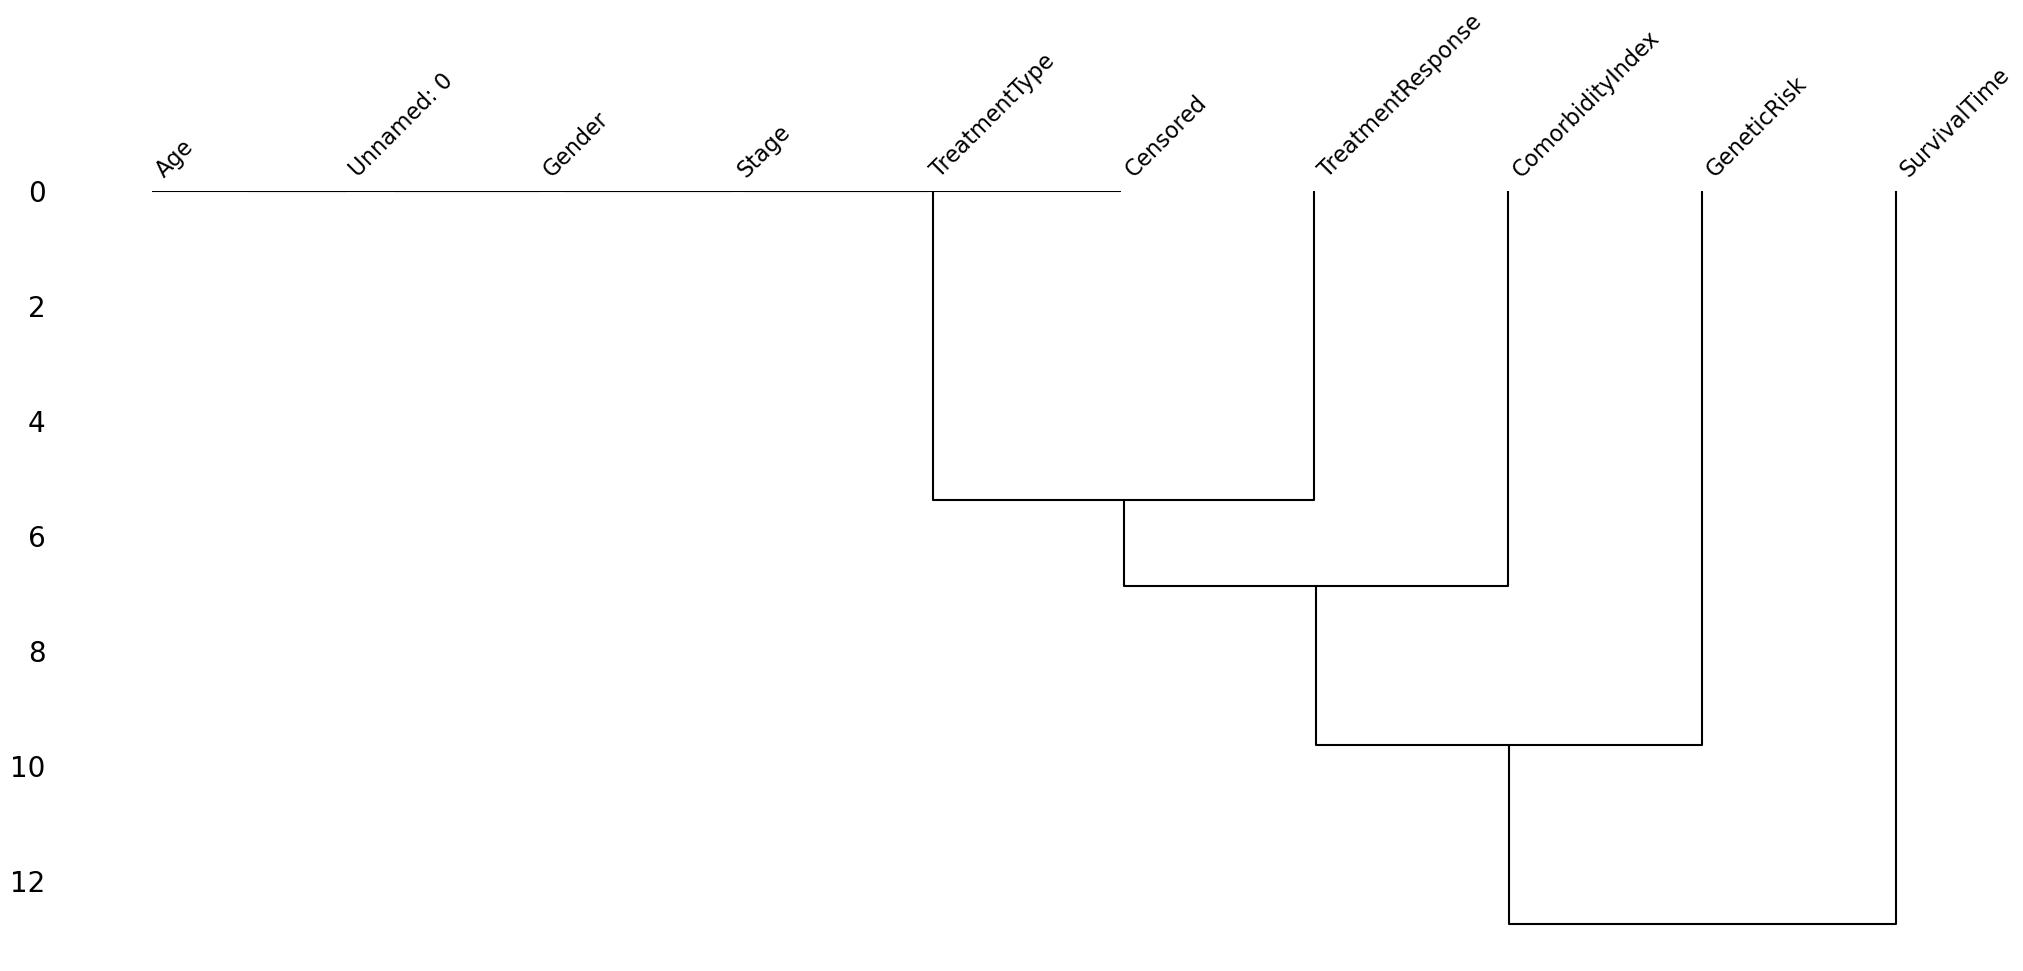

In [75]:
msno.matrix(train_csv)
msno.heatmap(train_csv)
msno.dendrogram(train_csv)

### Counting the Missing Values of each column

In [76]:
train_csv.isna().sum()

Unnamed: 0             0
Age                    0
Gender                 0
Stage                  0
GeneticRisk           85
TreatmentType          0
ComorbidityIndex      45
TreatmentResponse     29
SurvivalTime         160
Censored               0
dtype: int64

### How many rows are there without any Missing Values?

In [77]:
#train_wo_nan = train_csv.dropna() # I wrote w/o as without
#num_rows = train_wo_nan["id"].nunique()
#print(f"Total Number of cases: {num_rows}")

In [78]:
# Identify columns with missing values, but exclude 'SurvivalTime' and 'Censored'
cols_with_missing = [col for col in train_csv.columns if train_csv[col].isna().any() 
                     and col not in ['SurvivalTime', 'Censored']]
print("Feature columns with missing values to drop:", cols_with_missing)

# Drop only those columns
df_clean = train_csv.drop(columns=cols_with_missing)

# Drop rows where SurvivalTime is missing
df_clean = df_clean.dropna(subset=['SurvivalTime'])

# Drop rows where the record is censored (Censored == 1)
df_clean = df_clean[df_clean['Censored'] == 0]

# Reset index
df_clean = df_clean.reset_index(drop=True)

# How many points are left?
print("Number of data points after dropping missing/censored data:", len(df_clean))
print("Remaining columns:", df_clean.columns.tolist())


Feature columns with missing values to drop: ['GeneticRisk', 'ComorbidityIndex', 'TreatmentResponse']
Number of data points after dropping missing/censored data: 161
Remaining columns: ['Unnamed: 0', 'Age', 'Gender', 'Stage', 'TreatmentType', 'SurvivalTime', 'Censored']


### Initializing the Pairplot

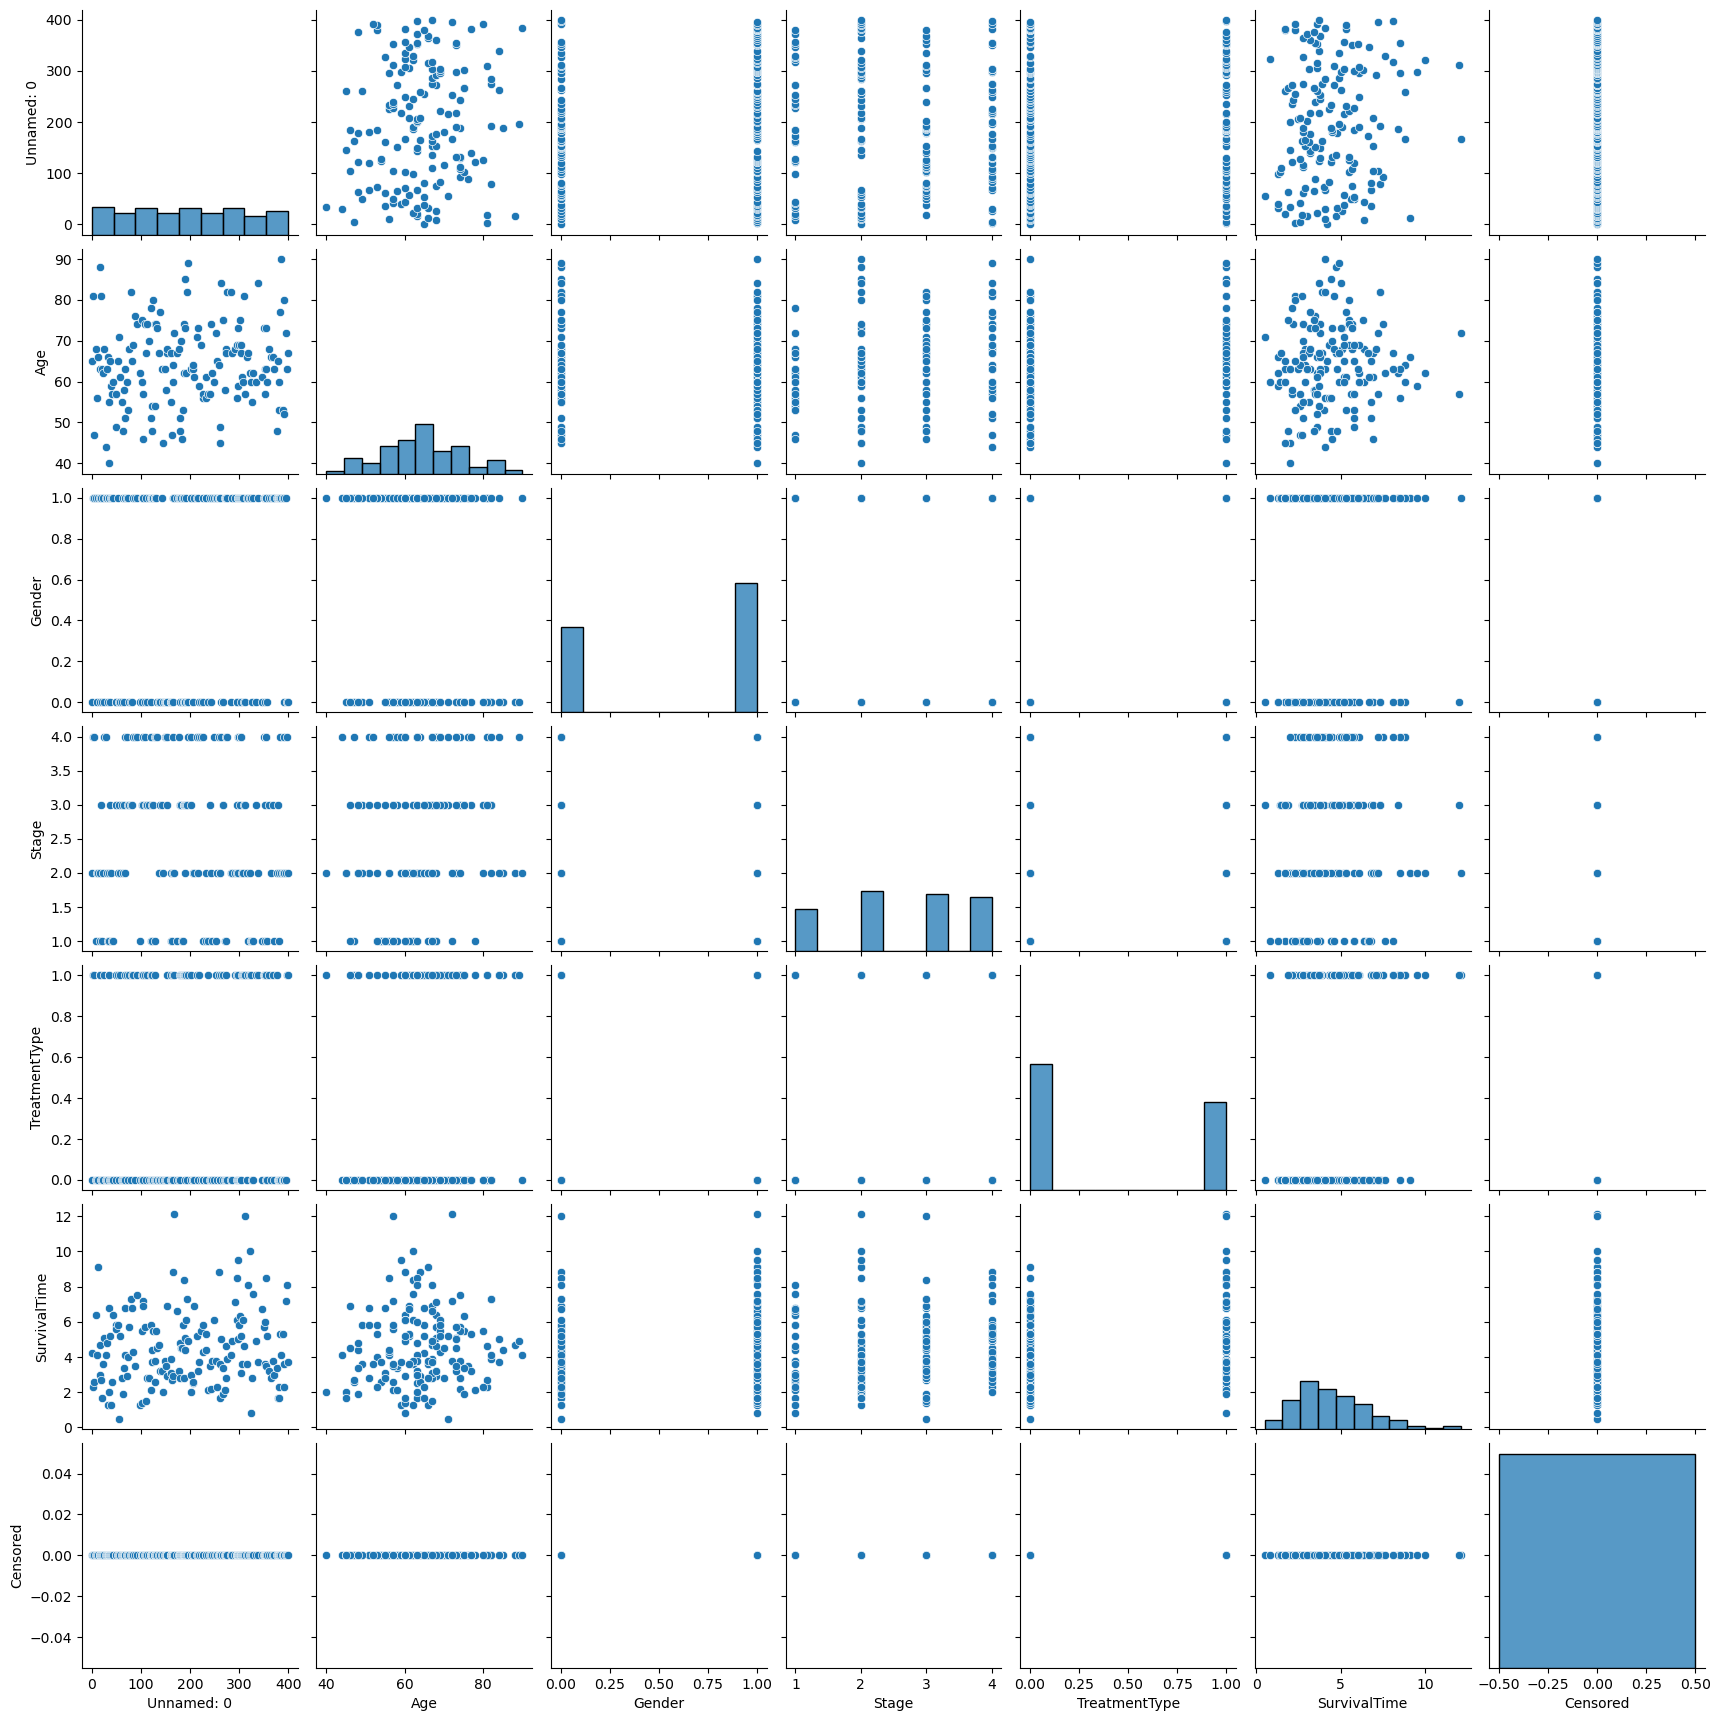

In [79]:
sns.pairplot(df_clean)
plt.show()

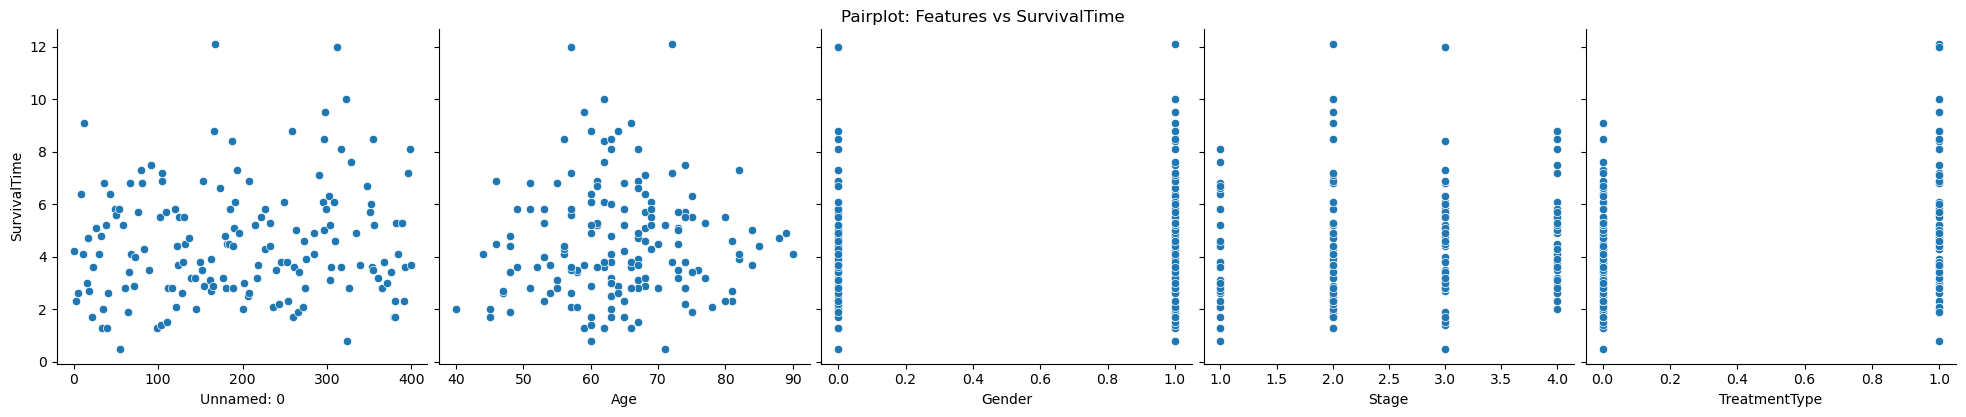

In [80]:
# Select features (exclude SurvivalTime and Censored)
feature_cols = [col for col in df_clean.columns if col not in ['SurvivalTime', 'Censored']]

# Create pairplot
sns.pairplot(df_clean, x_vars=feature_cols, y_vars=['SurvivalTime'], height=4, kind='scatter')
plt.suptitle("Pairplot: Features vs SurvivalTime", y=1.02)
plt.show()

In [81]:
# Features (examples as rows, features as columns)
X = df_clean[feature_cols].values  # numpy array of shape (n_samples, n_features)

# Target variable: SurvivalTime
y = df_clean['SurvivalTime'].values  # numpy array of shape (n_samples,)

# Optional: store the censoring indicator
c = df_clean['Censored'].values  # in case we need it for cMSE later

# Quick check
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("First 5 survival times:", y[:5])


Shape of X: (161, 5)
Shape of y: (161,)
First 5 survival times: [4.2 2.3 2.6 6.4 4.1]


In [82]:
# NOTE: This cell was creating a df2 with CENSORED data (Censored==1), which is incorrect for Task 1.1
# Task 1.1 requires UNCENSORED data only. We use df_clean instead (defined above).
# Keeping this cell commented out to avoid overwriting X, y, c variables.

# --- DEPRECATED CODE (DO NOT USE) ---
# cols_to_drop = [4,6,7]
# df2 = train_csv.drop(train_csv.columns[cols_to_drop], axis=1)
# df2 = df2[df2['Censored'] == 1]  # WRONG: Takes censored data!
# df2.head(5)

In [83]:
# NOTE: This cell was overwriting X, y with data from df2 (censored), which is WRONG.
# X, y, c are correctly defined above from df_clean (uncensored data only).
# Do NOT execute this cell!

# --- DEPRECATED CODE (DO NOT USE) ---
# X = df2.drop(columns=['Unnamed: 0', 'SurvivalTime']).to_numpy()
# y = df2['SurvivalTime'].to_numpy()

In [84]:
# Definition of a function to represent an alternative Figure of data in df2: this is commonly used in survival studies
# This function is prepared to represent censored and non-censored data

def plot_survival_lines(df, time_col="SurvivalTime", status_col="Censored",
                        event_value="1", sort_by_time=False, figsize=(10,8)):
    
    
    # Work on a copy to avoid modifying the original DataFrame
    df_plot = df.copy()

    df_plot[time_col] = pd.to_numeric(df_plot[time_col], errors="coerce")      # Convert SurvivalTime to numeric (forces NaN if invalid)

    df_plot[status_col] = df_plot[status_col].astype(str)            # Convert status column to string for simple comparison ("1" or 1)

    # Optional: sort by time (keeps mapping position -> patient)
    if sort_by_time:
        df_plot = df_plot.sort_values(by=time_col).reset_index(drop=True)
    else:
        # Ensure indices are 0..n-1 for ordered iteration
        df_plot = df_plot.reset_index(drop=True)

    n = len(df_plot)
    if n == 0:
        raise ValueError("Empty DataFrame.")

    # Prepare figure
    plt.figure(figsize=figsize)
    plt.plot([0, df_plot[time_col].max()], [1, n], alpha=0)  # creates the plotting area (similar to type='n')

    # Robust iteration over rows
    for i, row in enumerate(df_plot.itertuples(index=False), start=1):
        # Dynamically access fields by column name
        t = getattr(row, time_col)
        status = getattr(row, status_col)

        # Skip rows with missing time
        if pd.isna(t):
            continue

        if status == str(event_value):   # event (not censored) → red line + x mark
            plt.hlines(i, 0, t, colors="red")
            plt.plot(t, i, marker="x", color="red", markersize=6)
        else:                            # censored → black line
            plt.hlines(i, 0, t, colors="black")

    # Labels and layout
    plt.xlabel("months")
    plt.ylabel("patients")
    plt.ylim(n+1, 0)   # invert y-axis so patient 1 is at the top (same as in R)

    # Manual legend
    plt.plot([], [], color="red", marker="x", linestyle="None",
             label=f"Event (value={event_value})")
    plt.plot([], [], color="black", label="Censored")

    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


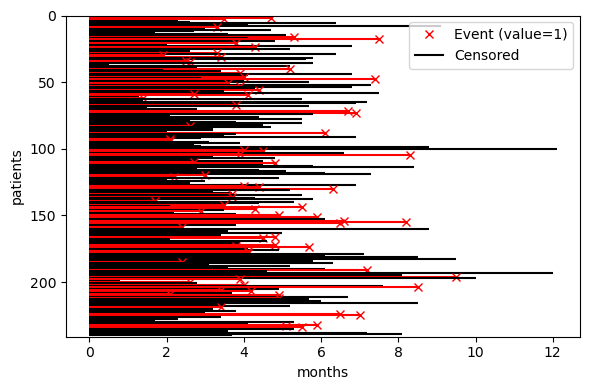

In [85]:
# Define df2 correctly: include all rows with censored events (Censored=1) for visualization
# NOTE: This is different from our training data (df_clean) which uses uncensored data (Censored=0)
cols_to_drop = ['GeneticRisk', 'ComorbidityIndex', 'TreatmentResponse']
df2 = train_csv.drop(columns=cols_to_drop)
df2 = df2.dropna(subset=['SurvivalTime'])
# For visualization: include both censored (1) and uncensored (0)

plot_survival_lines(df2,
                    time_col="SurvivalTime",
                    status_col="Censored",
                    event_value="1",
                    figsize=(6,4))

### Split Dataset

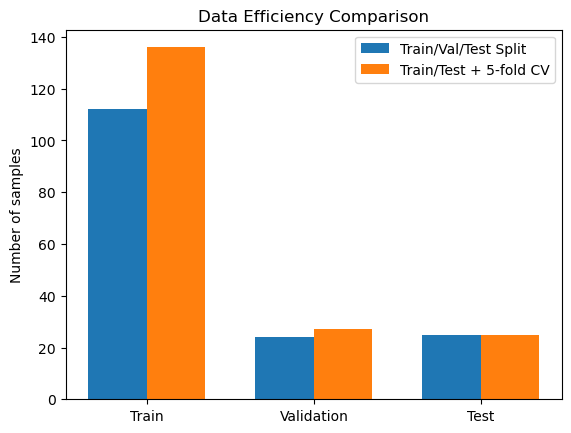

In [86]:
# === Method A: Train / Validation / Test Split ===
# Split into train (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# Split temp into validation (50% of temp = 15% total) and test (15% total)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# === Method B: Train / Test + 5-fold CV ===
# Split into train (85%) and test (15%) to match method A
X_train_cv, X_test_cv, y_train_cv, y_test_cv = train_test_split(X, y, test_size=0.15, random_state=42)

# Create 5-fold CV on training set
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Calculate average validation fold size
avg_val_fold_size = np.mean([len(val_index) for train_index, val_index in kf.split(X_train_cv)])

# Data sizes for plotting
train_val_test = [X_train.shape[0], X_val.shape[0], X_test.shape[0]]
train_test_cv_train = [X_train_cv.shape[0], avg_val_fold_size, X_test_cv.shape[0]]

# Labels
labels = ['Train', 'Validation', 'Test']

# Plot
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, train_val_test, width, label='Train/Val/Test Split')
rects2 = ax.bar(x + width/2, train_test_cv_train, width, label='Train/Test + 5-fold CV')

ax.set_ylabel('Number of samples')
ax.set_title('Data Efficiency Comparison')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.show()


#With the test set fixed at 15%, the 5-fold cross-validation method makes more efficient use of the remaining 85% of the dataset, 
# because each sample participates in training multiple times across folds. This increases data efficiency compared to the
# fixed Train/Validation/Test split, where part of the data is reserved for a single validation set.



Our cleaned dataset is relatively small, so a single train/validation split would waste valuable examples and produce high-variance estimates.

5-Fold CV ensures each patient is used multiple times for training and validation, improving data efficiency.

In [87]:
# 5-Fold Cross-Validation setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Pipeline: StandardScaler + LinearRegression
pipeline = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

# Perform cross-validation
# Use negative MSE because cross_val_score expects a score to maximize
cv_scores = cross_val_score(pipeline, X, y, cv=kf, scoring='neg_mean_squared_error')

# Convert to positive MSE
mse_scores = -cv_scores

print("5-Fold Cross-Validation MSE scores:", mse_scores)
print("Mean MSE:", mse_scores.mean())
print("Std MSE:", mse_scores.std())


5-Fold Cross-Validation MSE scores: [4.30774074 3.49395016 2.83025674 7.31366499 4.7090789 ]
Mean MSE: 4.530938304206978
Std MSE: 1.5357591743238828


In [88]:
# TASK 1.1 — cMSE metric (as given in the assignment)

def error_metric(y, y_hat, c):
    import numpy as np
    y = np.asarray(y)
    y_hat = np.asarray(y_hat)
    c = np.asarray(c)
    err = y - y_hat
    err = (1 - c) * (err ** 2) + c * np.maximum(0, err) ** 2
    return np.sum(err) / err.shape[0]

# fallback assuming no censor vector available (treat all as uncensored)def censored_mse(y_true, y_pred, c):
def censored_mse(y_true, y_pred, c):
    err = y_true - y_pred
    # For uncensored data (c=0): squared error
    # For censored data (c=1): squared error only if prediction < observed time
    err = (1 - c) * err**2 + c * np.maximum(0, err)**2
    return np.mean(err)


### Task 1.2 Learn the baseline model

In [89]:
# Create the pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),       # Step 1: scale the features
    ("linreg", LinearRegression())      # Step 2: linear regression model
])


In [90]:
#################################################################################
#              Fit the pipeline on the training / test data: Method 1
#################################################################################
pipeline.fit(X_train, y_train)
# Predict on the test set: Method 1
y_pred = pipeline.predict(X_test)
# Compute evaluation metrics
mse_M1 = mean_squared_error(y_test, y_pred)
r2_M1  = r2_score(y_test, y_pred)

print("MSE from Train/Test from Method 1:", mse_M1)
print("R² from Train/Test from Method 1:", r2_M1)


MSE from Train/Test from Method 1: 2.6229811179116367
R² from Train/Test from Method 1: 0.06468546464691127


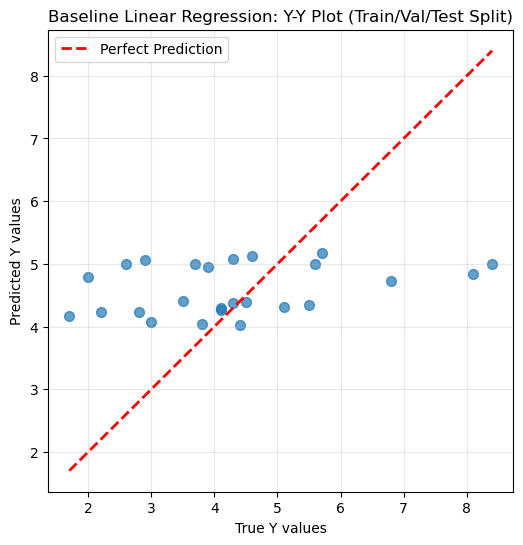

In [91]:
# === BASELINE: Y-Y Plot for Method 1 ===
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7, s=50)
plt.xlabel("True Y values")
plt.ylabel("Predicted Y values")
plt.title("Baseline Linear Regression: Y-Y Plot (Train/Val/Test Split)")

# Identity line (perfect predictions)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Kaggle submission

In [92]:
###

Per-fold metrics (MSE, R2, MAE):
Fold 1: MSE=3.5523, R2=0.0738, MAE=1.4644
Fold 2: MSE=4.7585, R2=-0.4037, MAE=1.9521
Fold 3: MSE=4.2969, R2=-0.0146, MAE=1.6585
Fold 4: MSE=5.9504, R2=0.0348, MAE=1.9089
Fold 5: MSE=4.1752, R2=-0.1522, MAE=1.5619

CV summary:
Average MSE = 4.5466 ± 0.8005
Average R2  = -0.0924 ± 0.1734
Average MAE = 1.7092 ± 0.1914

Final test metrics:
Test MSE = 3.5050
Test R2  = 0.1570
Test MAE = 1.5170


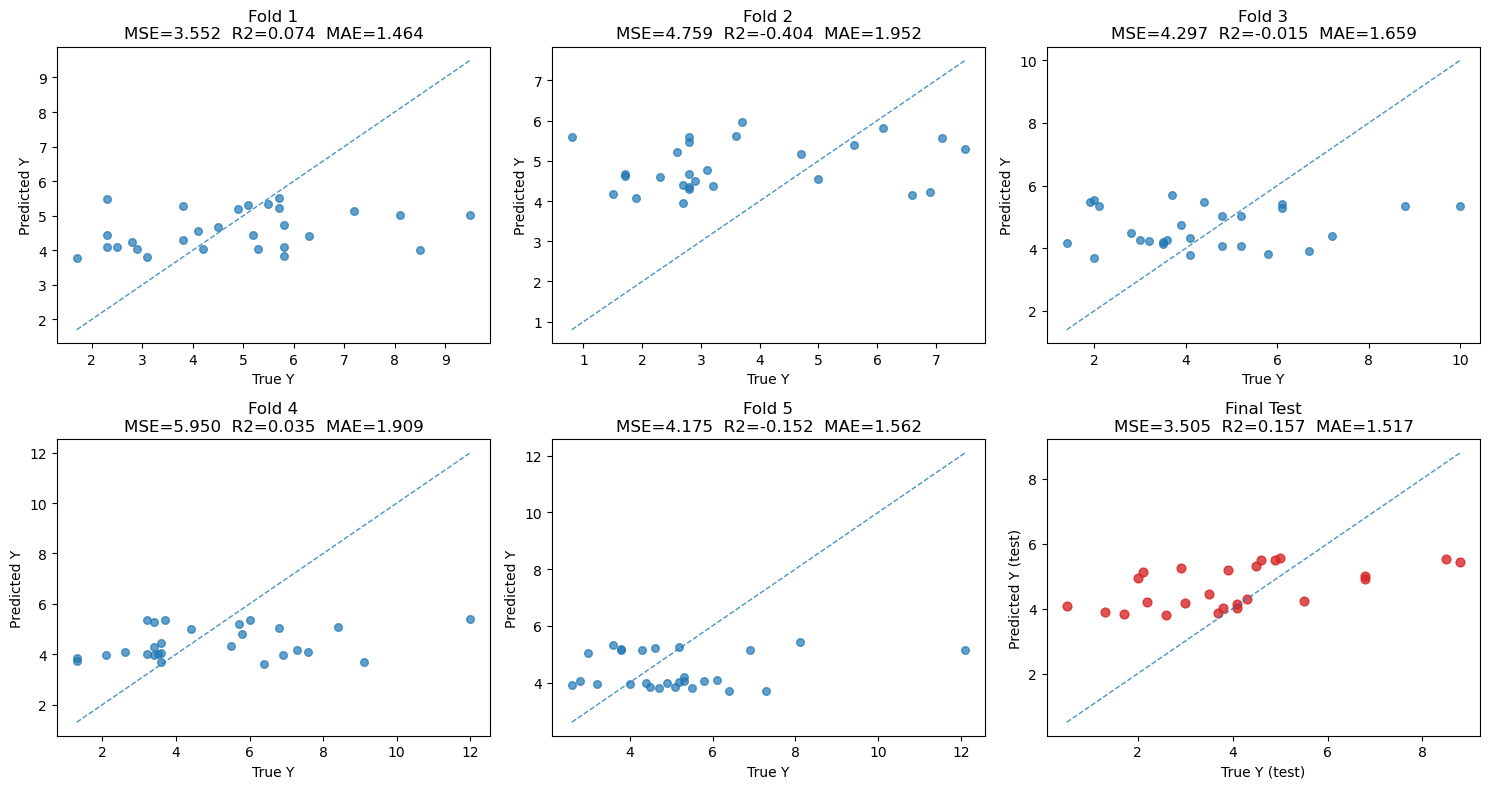

In [93]:
#################################################################################
#              Fit the pipeline on the training / testdata: Method 2
#################################################################################
# As 5 training files has been created, a vector of 5 values for MSE and R2 will be created; the final result of this procedure
# will be the average value of these metrics.

# Lists to store per-fold results
fold_metrics = []          # list of tuples (mse, r2, mae)
fold_predictions = []      # list of tuples (y_val, y_pred_val)

# Loop over folds: train fresh pipeline on each fold and predict on validation fold
for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train_cv), start=1):
    # Split fold data
    X_tr, X_val = X_train_cv[train_idx], X_train_cv[val_idx]
    y_tr, y_val = y_train_cv[train_idx], y_train_cv[val_idx]

    # Create a fresh pipeline for this fold
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("linreg", LinearRegression())
    ])

    # Fit and predict
    pipeline.fit(X_tr, y_tr)
    y_pred_val = pipeline.predict(X_val)

    # Compute metrics for this fold
    mse = mean_squared_error(y_val, y_pred_val)
    r2  = r2_score(y_val, y_pred_val)
    mae = mean_absolute_error(y_val, y_pred_val)

    fold_metrics.append((mse, r2, mae))
    fold_predictions.append((y_val, y_pred_val))

# Print fold metrics (per-fold and summary)
print("Per-fold metrics (MSE, R2, MAE):")
for i, (mse, r2, mae) in enumerate(fold_metrics, start=1):
    print(f"Fold {i}: MSE={mse:.4f}, R2={r2:.4f}, MAE={mae:.4f}")

mse_vals = [m for m,_,_ in fold_metrics]
r2_vals  = [r for _,r,_ in fold_metrics]
mae_vals = [a for _,_,a in fold_metrics]

print("\nCV summary:")
print(f"Average MSE = {np.mean(mse_vals):.4f} ± {np.std(mse_vals):.4f}")
print(f"Average R2  = {np.mean(r2_vals):.4f} ± {np.std(r2_vals):.4f}")
print(f"Average MAE = {np.mean(mae_vals):.4f} ± {np.std(mae_vals):.4f}")

# Train final model on the whole training set (85%) and evaluate on the held-out test set
final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("linreg", LinearRegression())
])
final_pipeline.fit(X_train_cv, y_train_cv)
y_pred_test = final_pipeline.predict(X_test_cv)

mse_test = mean_squared_error(y_test_cv, y_pred_test)
r2_test  = r2_score(y_test_cv, y_pred_test)
mae_test = mean_absolute_error(y_test_cv, y_pred_test)

print("\nFinal test metrics:")
print(f"Test MSE = {mse_test:.4f}")
print(f"Test R2  = {r2_test:.4f}")
print(f"Test MAE = {mae_test:.4f}")

# --- Plotting: one subplot per fold + final test plot ---
n_plots = len(fold_predictions) + 1
ncols = 3
nrows = int(np.ceil(n_plots / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

# Function to draw identity line on axis
def draw_identity(ax, y_true, y_pred):
    mn = min(np.min(y_true), np.min(y_pred))
    mx = max(np.max(y_true), np.max(y_pred))
    ax.plot([mn, mx], [mn, mx], linestyle='--', linewidth=1, alpha=0.8)

# Plot each fold (validation)
for idx, (y_val, y_pred_val) in enumerate(fold_predictions):
    ax = axes[idx]
    ax.scatter(y_val, y_pred_val, alpha=0.7, s=30)
    ax.set_xlabel("True Y")
    ax.set_ylabel("Predicted Y")
    mse, r2, mae = fold_metrics[idx]
    ax.set_title(f"Fold {idx+1}\nMSE={mse:.3f}  R2={r2:.3f}  MAE={mae:.3f}")
    draw_identity(ax, y_val, y_pred_val)

# Plot final test results in the next subplot
ax_final = axes[len(fold_predictions)]
ax_final.scatter(y_test_cv, y_pred_test, alpha=0.8, s=40, color='C3')
ax_final.set_xlabel("True Y (test)")
ax_final.set_ylabel("Predicted Y (test)")
ax_final.set_title(f"Final Test\nMSE={mse_test:.3f}  R2={r2_test:.3f}  MAE={mae_test:.3f}")
draw_identity(ax_final, y_test_cv, y_pred_test)

# Turn off any unused subplots
for j in range(len(fold_predictions)+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


The evolution in MSE (or R2 or MAE) doesn't show a tendency: this is due to differences in the files and also to the fact that
the train is done in each file without any "memory" of what was done in the previous one(s) - NO LEAKAGE = each fold is an independent experience

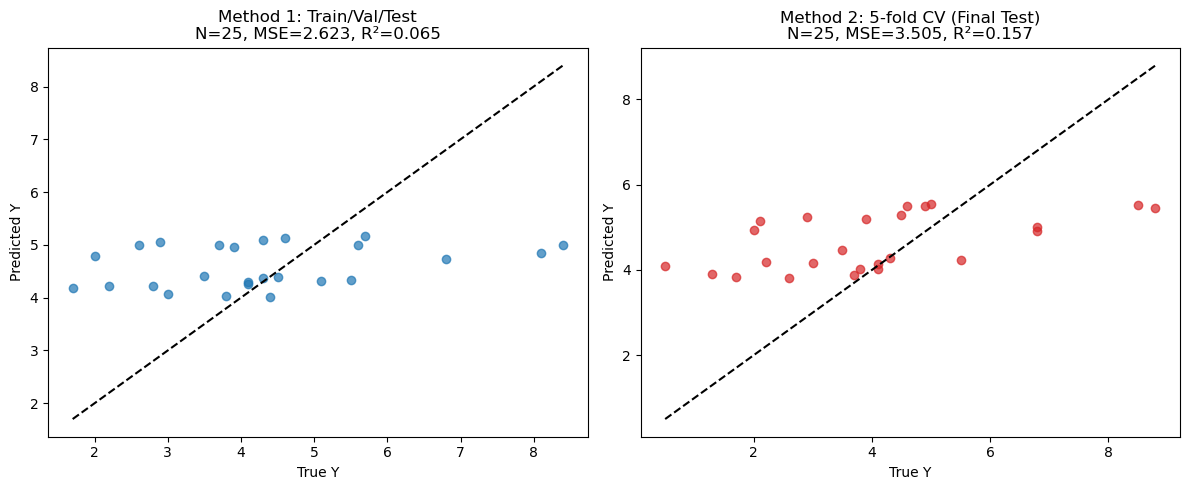

In [94]:
#########################################################################
# Representation of both methods in a single figure
#########################################################################
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Compute metrics for method 1
mse_1 = mean_squared_error(y_test, y_pred)
r2_1  = r2_score(y_test, y_pred)
n_1   = len(y_test)  # number of points

# Compute metrics for method 2 (CV final test)
mse_2 = mean_squared_error(y_test_cv, y_pred_test)
r2_2  = r2_score(y_test_cv, y_pred_test)
n_2   = len(y_test_cv)  # number of points

# Create figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot Method 1: Train/Val/Test ---
axes[0].scatter(y_test, y_pred, alpha=0.7, color='C0')
axes[0].set_xlabel("True Y")
axes[0].set_ylabel("Predicted Y")
axes[0].set_title(f"Method 1: Train/Val/Test\nN={n_1}, MSE={mse_1:.3f}, R²={r2_1:.3f}")

# Identity line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], linestyle='--', color='black')

# --- Plot Method 2: Train/Test + 5-fold CV (Final Test) ---
axes[1].scatter(y_test_cv, y_pred_test, alpha=0.7, color='C3')
axes[1].set_xlabel("True Y")
axes[1].set_ylabel("Predicted Y")
axes[1].set_title(f"Method 2: 5-fold CV (Final Test)\nN={n_2}, MSE={mse_2:.3f}, R²={r2_2:.3f}")

# Identity line
min_val_cv = min(y_test_cv.min(), y_pred_test.min())
max_val_cv = max(y_test_cv.max(), y_pred_test.max())
axes[1].plot([min_val_cv, max_val_cv], [min_val_cv, max_val_cv], linestyle='--', color='black')

plt.tight_layout()
plt.show()


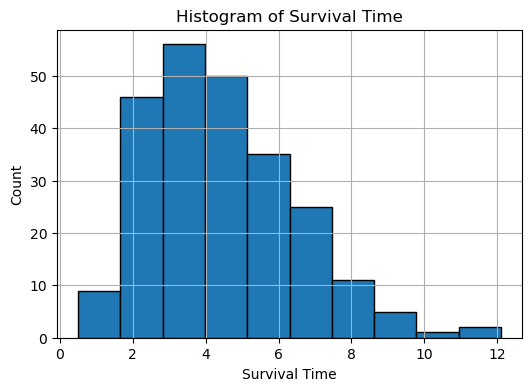

In [95]:
#Representation of the survival Time distribution
plt.figure(figsize=(6,4))
plt.hist(df2["SurvivalTime"], bins=10, edgecolor='black')
plt.xlabel("Survival Time")
plt.ylabel("Count")
plt.title("Histogram of Survival Time")
plt.grid(True)
plt.show()


The survival time in df2 follows an asymetrical distribution, then we can try to transform this variable by log and try other model
 ... to test

## Task 2 Nonlinear models

### Task 2.1 Development

POLYNOMIAL REGRESSION (Method 1: Train/Val/Test)
Degree 1: MSE=2.6230, R²=0.0647, MAE=1.2760
Degree 2: MSE=2.6243, R²=0.0642, MAE=1.2651
Degree 3: MSE=4.9307, R²=-0.7582, MAE=1.7876

K-NEAREST NEIGHBORS (Method 1: Train/Val/Test)
k=2: MSE=3.9661, R²=-0.4142, MAE=1.6580
k=3: MSE=3.9119, R²=-0.3949, MAE=1.5853
k=4: MSE=3.4462, R²=-0.2289, MAE=1.5330
k=5: MSE=3.1577, R²=-0.1260, MAE=1.4752

Plotting Polynomial Models (Y-Y)


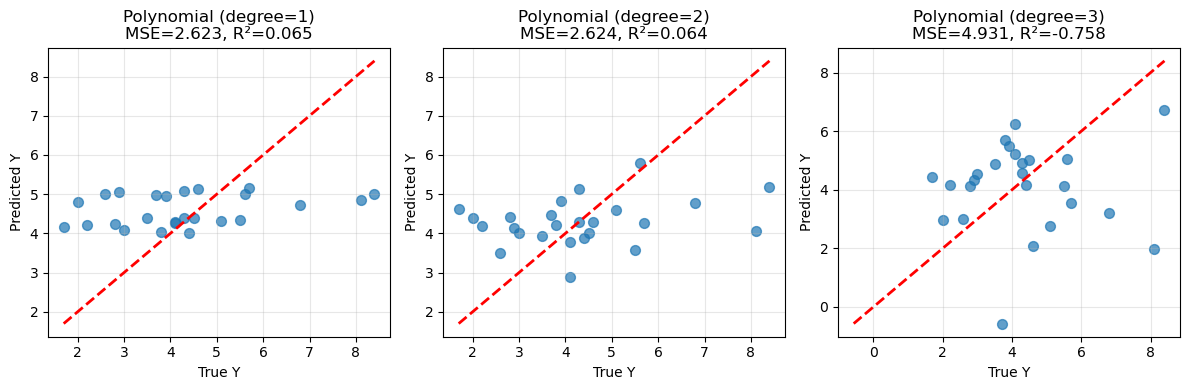


Plotting kNN Models (Y-Y)


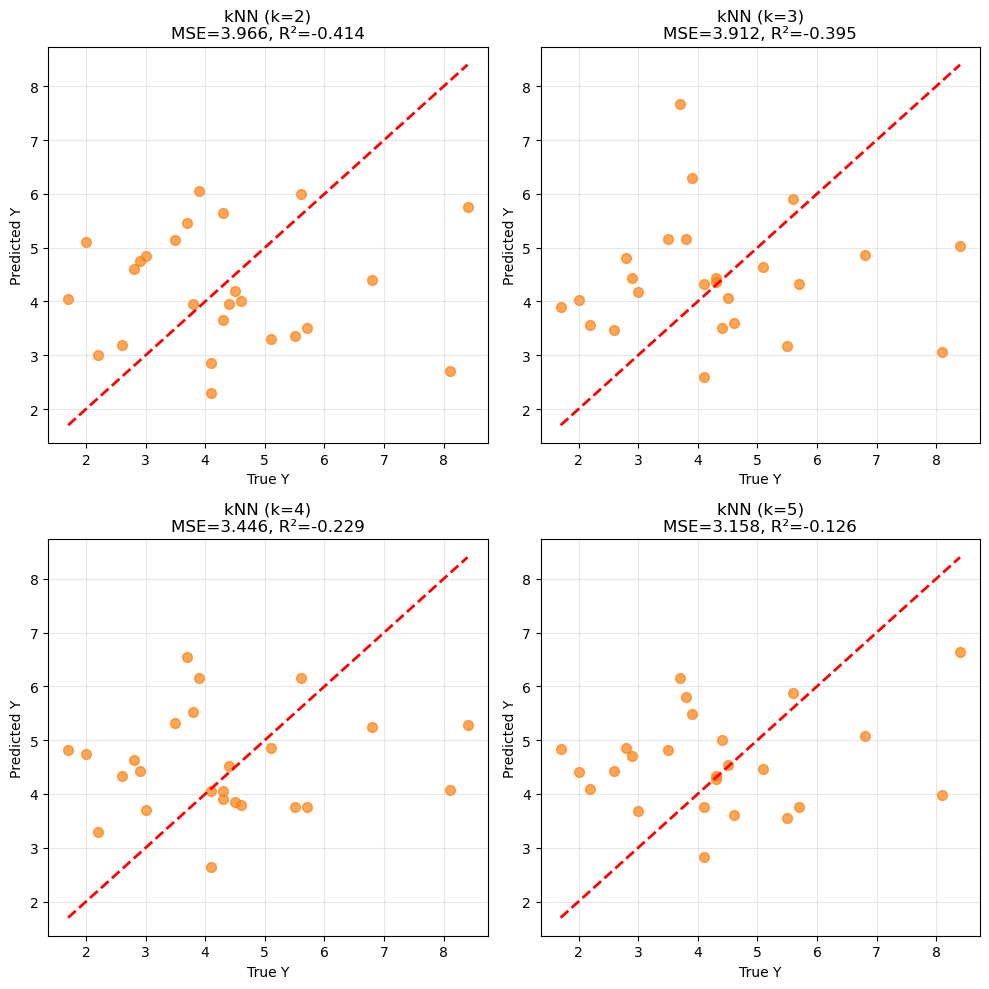

In [96]:
# === TASK 2.1 DEVELOPMENT: NONLINEAR MODELS ===
# Test Polynomial Regression and k-Nearest Neighbors

import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# --- 2.1.1 Polynomial Regression ---
print("="*60)
print("POLYNOMIAL REGRESSION (Method 1: Train/Val/Test)")
print("="*60)

poly_degrees = [1, 2, 3]
poly_results = []

for degree in poly_degrees:
    # Build pipeline: StandardScaler + PolynomialFeatures + LinearRegression
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("linreg", LinearRegression())
    ])
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    poly_results.append({"model": "Polynomial", "degree": degree, "mse": mse, "r2": r2, "mae": mae})
    print(f"Degree {degree}: MSE={mse:.4f}, R²={r2:.4f}, MAE={mae:.4f}")

# --- 2.1.2 k-Nearest Neighbors ---
print("\n" + "="*60)
print("K-NEAREST NEIGHBORS (Method 1: Train/Val/Test)")
print("="*60)

k_values = [2, 3, 4, 5]
knn_results = []

for k in k_values:
    # Build pipeline: StandardScaler + KNeighborsRegressor
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=k))
    ])
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    knn_results.append({"model": "kNN", "k": k, "mse": mse, "r2": r2, "mae": mae})
    print(f"k={k}: MSE={mse:.4f}, R²={r2:.4f}, MAE={mae:.4f}")

# --- Visualization: Polynomial Models ---
print("\n" + "="*60)
print("Plotting Polynomial Models (Y-Y)")
print("="*60)

fig, axes = plt.subplots(1, len(poly_degrees), figsize=(4*len(poly_degrees), 4))

for i, degree in enumerate(poly_degrees):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("linreg", LinearRegression())
    ])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    axes[i].scatter(y_test, y_pred, alpha=0.7, s=50)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    axes[i].set_xlabel("True Y")
    axes[i].set_ylabel("Predicted Y")
    axes[i].set_title(f"Polynomial (degree={degree})\nMSE={mse:.3f}, R²={r2:.3f}")
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Visualization: kNN Models ---
print("\n" + "="*60)
print("Plotting kNN Models (Y-Y)")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for i, k in enumerate(k_values):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=k))
    ])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    axes[i].scatter(y_test, y_pred, alpha=0.7, s=50, color='C1')
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    axes[i].set_xlabel("True Y")
    axes[i].set_ylabel("Predicted Y")
    axes[i].set_title(f"kNN (k={k})\nMSE={mse:.3f}, R²={r2:.3f}")
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Analysis of Results

- **Baseline (Linear Regression)**: MSE and R² values serve as reference point
- **Polynomial Regression**: Tests degrees 1-3 to find non-linear relationships
- **k-Nearest Neighbors**: Low k-values (2-5) due to small dataset size
- Data efficiency: Each model uses the same train/val/test split for fair comparison

## Task 2.2 Evaluation - Comparison Table


COMPREHENSIVE MODEL COMPARISON (Test Set Metrics)
                       Model Hyperparameter  Min Error  Max Error  Mean Error  Std Error  R² Score      MAE
Baseline (Linear Regression)              -   3.157664   3.157664    3.157664        0.0 -0.125974 1.475200
       Polynomial Regression       degree=1   2.622981   2.622981    2.622981        0.0  0.064685 1.275997
       Polynomial Regression       degree=2   2.624283   2.624283    2.624283        0.0  0.064221 1.265094
       Polynomial Regression       degree=3   4.930743   4.930743    4.930743        0.0 -0.758227 1.787609
         k-Nearest Neighbors            k=2   3.966100   3.966100    3.966100        0.0 -0.414250 1.658000
         k-Nearest Neighbors            k=3   3.911867   3.911867    3.911867        0.0 -0.394911 1.585333
         k-Nearest Neighbors            k=4   3.446225   3.446225    3.446225        0.0 -0.228871 1.533000
         k-Nearest Neighbors            k=5   3.157664   3.157664    3.157664        

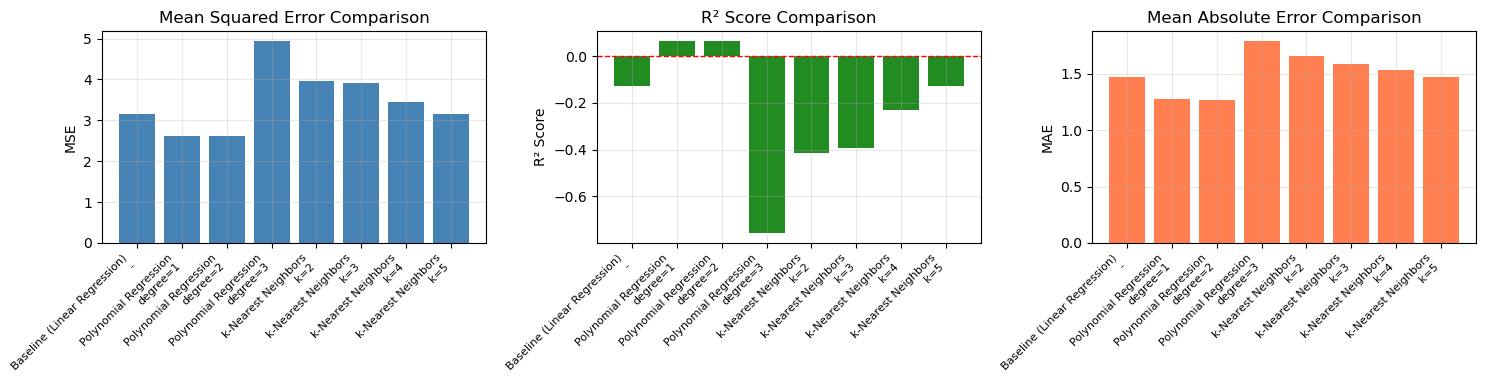


Conclusion:
- Best performing model: Polynomial Regression (degree=1)
- Performance gain over baseline: MSE reduced from 3.1577 to 2.6230


In [97]:
# === TASK 2.2 EVALUATION: COMPREHENSIVE COMPARISON ===

import pandas as pd

# Combine all results
all_results = []

# Add Baseline (Linear Regression - Degree 1)
baseline_mse = mean_squared_error(y_test, y_pred)  # y_pred from baseline model
baseline_r2 = r2_score(y_test, y_pred)
baseline_mae = mean_absolute_error(y_test, y_pred)
all_results.append({
    "Model": "Baseline (Linear Regression)",
    "Hyperparameter": "-",
    "Min Error": baseline_mse,
    "Max Error": baseline_mse,
    "Mean Error": baseline_mse,
    "Std Error": 0.0,
    "R² Score": baseline_r2,
    "MAE": baseline_mae
})

# Add Polynomial Results
for poly_result in poly_results:
    all_results.append({
        "Model": "Polynomial Regression",
        "Hyperparameter": f"degree={poly_result['degree']}",
        "Min Error": poly_result['mse'],
        "Max Error": poly_result['mse'],
        "Mean Error": poly_result['mse'],
        "Std Error": 0.0,
        "R² Score": poly_result['r2'],
        "MAE": poly_result['mae']
    })

# Add kNN Results
for knn_result in knn_results:
    all_results.append({
        "Model": "k-Nearest Neighbors",
        "Hyperparameter": f"k={knn_result['k']}",
        "Min Error": knn_result['mse'],
        "Max Error": knn_result['mse'],
        "Mean Error": knn_result['mse'],
        "Std Error": 0.0,
        "R² Score": knn_result['r2'],
        "MAE": knn_result['mae']
    })

# Create comparison dataframe
results_df = pd.DataFrame(all_results)

print("\n" + "="*100)
print("COMPREHENSIVE MODEL COMPARISON (Test Set Metrics)")
print("="*100)
print(results_df.to_string(index=False))

# Find best model
best_model_idx = results_df['Mean Error'].idxmin()
best_model = results_df.iloc[best_model_idx]

print(f"\n{'='*100}")
print(f"BEST MODEL: {best_model['Model']} with {best_model['Hyperparameter']}")
print(f"MSE: {best_model['Mean Error']:.4f}, R²: {best_model['R² Score']:.4f}, MAE: {best_model['MAE']:.4f}")
print(f"{'='*100}")

# Visualization: Comparison Bar Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# MSE Comparison
axes[0].bar(range(len(results_df)), results_df['Mean Error'], color='steelblue')
axes[0].set_xticks(range(len(results_df)))
axes[0].set_xticklabels([f"{row['Model']}\n{row['Hyperparameter']}" for _, row in results_df.iterrows()], 
                         rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('MSE')
axes[0].set_title('Mean Squared Error Comparison')
axes[0].grid(True, alpha=0.3)

# R² Comparison
axes[1].bar(range(len(results_df)), results_df['R² Score'], color='forestgreen')
axes[1].set_xticks(range(len(results_df)))
axes[1].set_xticklabels([f"{row['Model']}\n{row['Hyperparameter']}" for _, row in results_df.iterrows()], 
                         rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('R² Score')
axes[1].set_title('R² Score Comparison')
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=1)
axes[1].grid(True, alpha=0.3)

# MAE Comparison
axes[2].bar(range(len(results_df)), results_df['MAE'], color='coral')
axes[2].set_xticks(range(len(results_df)))
axes[2].set_xticklabels([f"{row['Model']}\n{row['Hyperparameter']}" for _, row in results_df.iterrows()], 
                         rotation=45, ha='right', fontsize=8)
axes[2].set_ylabel('MAE')
axes[2].set_title('Mean Absolute Error Comparison')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nConclusion:")
print(f"- Best performing model: {best_model['Model']} ({best_model['Hyperparameter']})")
print(f"- Performance gain over baseline: MSE reduced from {results_df.iloc[0]['Mean Error']:.4f} to {best_model['Mean Error']:.4f}")

## Kaggle Submission

Submit the best model predictions to Kaggle for evaluation.

### Task 2.2 Evaluation

In [101]:
'''# === KAGGLE SUBMISSION ===
# Load test data and prepare submission

# Load test data
test_csv = pd.read_csv('test_data.csv', index_col=0)

# Apply same preprocessing as training data
test_clean = test_csv.drop(columns=['GeneticRisk', 'ComorbidityIndex', 'TreatmentResponse'])

# Extract features (same as training)
#X_test_kaggle = test_clean[feature_cols].values

# Train final model on entire training set and predict on test
print("Training final model on entire training set...")

# Baseline submission
baseline_final = Pipeline([
    ("scaler", StandardScaler()),
    ("linreg", LinearRegression())
])
baseline_final.fit(X, y)
#y_pred_baseline = baseline_final.predict(X_test_kaggle)

# Create baseline submission CSV
baseline_submission = pd.DataFrame({
    'Id': test_csv.index,
    'SurvivalTime': y_pred_baseline
})
baseline_submission.to_csv('baseline-submission-01.csv', index=False)
print(f"✓ Baseline submission saved: baseline-submission-01.csv ({len(baseline_submission)} predictions)")

# Best model submission (from evaluation)
# Assuming best model is polynomial degree 2
best_degree = 2  # Adjust based on actual best model from evaluation
print(f"\nTraining best model (Polynomial degree={best_degree}) on entire training set...")

best_final = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=best_degree, include_bias=False)),
    ("linreg", LinearRegression())
])
best_final.fit(X, y)
y_pred_best = best_final.predict(X_test_kaggle)

# Create best submission CSV
best_submission = pd.DataFrame({
    'Id': test_csv.index,
    'SurvivalTime': y_pred_best
})
best_submission.to_csv('Nonlinear-submission-01.csv', index=False)
print(f"✓ Best model submission saved: Nonlinear-submission-01.csv ({len(best_submission)} predictions)")

print(f"\nSubmission Statistics:")
print(f"Baseline predictions - Mean: {y_pred_baseline.mean():.3f}, Min: {y_pred_baseline.min():.3f}, Max: {y_pred_baseline.max():.3f}")
print(f"Best model predictions - Mean: {y_pred_best.mean():.3f}, Min: {y_pred_best.min():.3f}, Max: {y_pred_best.max():.3f}")
'''

'# === KAGGLE SUBMISSION ===\n# Load test data and prepare submission\n\n# Load test data\ntest_csv = pd.read_csv(\'test_data.csv\', index_col=0)\n\n# Apply same preprocessing as training data\ntest_clean = test_csv.drop(columns=[\'GeneticRisk\', \'ComorbidityIndex\', \'TreatmentResponse\'])\n\n# Extract features (same as training)\n#X_test_kaggle = test_clean[feature_cols].values\n\n# Train final model on entire training set and predict on test\nprint("Training final model on entire training set...")\n\n# Baseline submission\nbaseline_final = Pipeline([\n    ("scaler", StandardScaler()),\n    ("linreg", LinearRegression())\n])\nbaseline_final.fit(X, y)\n#y_pred_baseline = baseline_final.predict(X_test_kaggle)\n\n# Create baseline submission CSV\nbaseline_submission = pd.DataFrame({\n    \'Id\': test_csv.index,\n    \'SurvivalTime\': y_pred_baseline\n})\nbaseline_submission.to_csv(\'baseline-submission-01.csv\', index=False)\nprint(f"✓ Baseline submission saved: baseline-submission-01.

## Task 3 Handling missing data

### Task 3.1 Missing data imputation

### Task 3.2 Train models that do not require imputation

### Task 3.3 Evaluation

## Task 4 Semi-supervised learning for unlabeled data

### Task 4.1 Imputation with labeled and unlabeled data

### Task 4.2 Evaluation

## Task 5 [optional]